# Futures/Spot HBT Step-by-Step Runner

The notebook is intentionally thin. Configuration, pipeline stages, report tables, and plotting live in separate Python scripts in this folder. Both this notebook and `run_full_backtest.py` save CSV reports and PNG figures.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. Parameters

In [2]:
args = default_notebook_args(
    start_date='2026-03-01',
    end_date='2026-03-31',
    order_latency_ms=10.0,
    response_latency_ms=10.0,
    feed_latency_offset_ms=10.0,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=True,
)
args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms')

## 2. Full Backtest and Core CSV Outputs

In [3]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

input_rows=112543
converted_rows=112137
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=406
raw_events=1356231
output_events=1356231
depth_events=1342272
trade_events=13959
opening_jump_qty=0.0
first_exch_ts=1772413200996833000
last_exch_ts=1772429099727293000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=0.000000
event_build_seconds=2.711084
normalize_seconds=0.000000
write_seconds=0.778483
output=/home/zoufuc/hftbacktest/data/tw_stock_events/1303_20260302_090000_132500.npz
input_rows=52095
converted_rows=52095
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=626634
output_events=626634
depth_events=625140
trade_events=1494
opening_jump_qty=0.0
first_exch_ts=1772413200698000000
last_exch_ts=1772417102873000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=2.65167

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,step_ns,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,strategy_engine,scan_calls,python_decisions
0,2026-03-02,2026-03-02::1303_CAFC6,1303_CAFC6,1303,CAFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
1,2026-03-02,2026-03-02::2002_CBFC6,2002_CBFC6,2002,CBFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
2,2026-03-02,2026-03-02::1301_CFFC6,1301_CFFC6,1301,CFFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
3,2026-03-02,2026-03-02::2324_CGFC6,2324_CGFC6,2324,CGFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
4,2026-03-02,2026-03-02::2409_CHFC6,2409_CHFC6,2409,CHFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
5,2026-03-02,2026-03-02::1605_CSFC6,1605_CSFC6,1605,CSFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
6,2026-03-02,2026-03-02::2408_CYFC6,2408_CYFC6,2408,CYFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
7,2026-03-02,2026-03-02::2603_CZFC6,2603_CZFC6,2603,CZFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
8,2026-03-02,2026-03-02::2609_DAFC6,2609_DAFC6,2609,DAFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264
9,2026-03-02,2026-03-02::1326_DGFC6,1326_DGFC6,1326,DGFC6,0,0,0,0,0.0,...,1000000000,0,spot,5000000000,10000000,10000000,10000000,numba,265,264


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-03-02,2026-03-02::1303_CAFC6,1303_CAFC6,0,0,0,0
1,2026-03-02,2026-03-02::2002_CBFC6,2002_CBFC6,0,0,0,0
2,2026-03-02,2026-03-02::1301_CFFC6,1301_CFFC6,0,0,0,0
3,2026-03-02,2026-03-02::2324_CGFC6,2324_CGFC6,0,0,0,0
4,2026-03-02,2026-03-02::2409_CHFC6,2409_CHFC6,0,0,0,0
5,2026-03-02,2026-03-02::1605_CSFC6,1605_CSFC6,0,0,0,0
6,2026-03-02,2026-03-02::2408_CYFC6,2408_CYFC6,0,0,0,0
7,2026-03-02,2026-03-02::2603_CZFC6,2603_CZFC6,0,0,0,0
8,2026-03-02,2026-03-02::2609_DAFC6,2609_DAFC6,0,0,0,0
9,2026-03-02,2026-03-02::1326_DGFC6,1326_DGFC6,0,0,0,0


## 3. Analysis CSV Outputs

In [4]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('roi_summary_including_open'))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,3189,13,1,166485.6460,12806.588154,100,0,0,0.0
1,2485,14,1,81956.1464,5854.010457,80,3,0,20.0
2,1303,16,2,64129.8642,4008.116512,160,1,0,40.0
3,3037,2,1,60578.1890,30289.094500,20,0,0,0.0
4,8150,4,1,44166.3078,11041.576950,40,0,0,0.0
5,2489,4,2,34917.0864,8729.271600,20,0,0,0.0
6,2313,16,2,32692.6400,2043.290000,40,0,0,0.0
7,2408,17,2,29923.2830,1760.193118,40,0,0,0.0
8,2615,7,1,22862.2228,3266.031829,20,0,0,0.0
9,6770,22,2,10672.5862,485.117555,28,0,0,0.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,3,4,84,3,2,0.0


,entry_cash_out,net_stock_cash_stuck,realized_pnl,open_locked_pnl,total_pnl_including_open,total_roi_on_entry_cash_pct,open_roi_on_stuck_cash_pct,open_pairs
0,9.171978e+07,8.988544e+06,557418.4584,87541.0702,644959.5286,0.007032,0.009739,60.0


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/reports


## 4. Saved PNG Outputs

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/figures/performance_overview.png


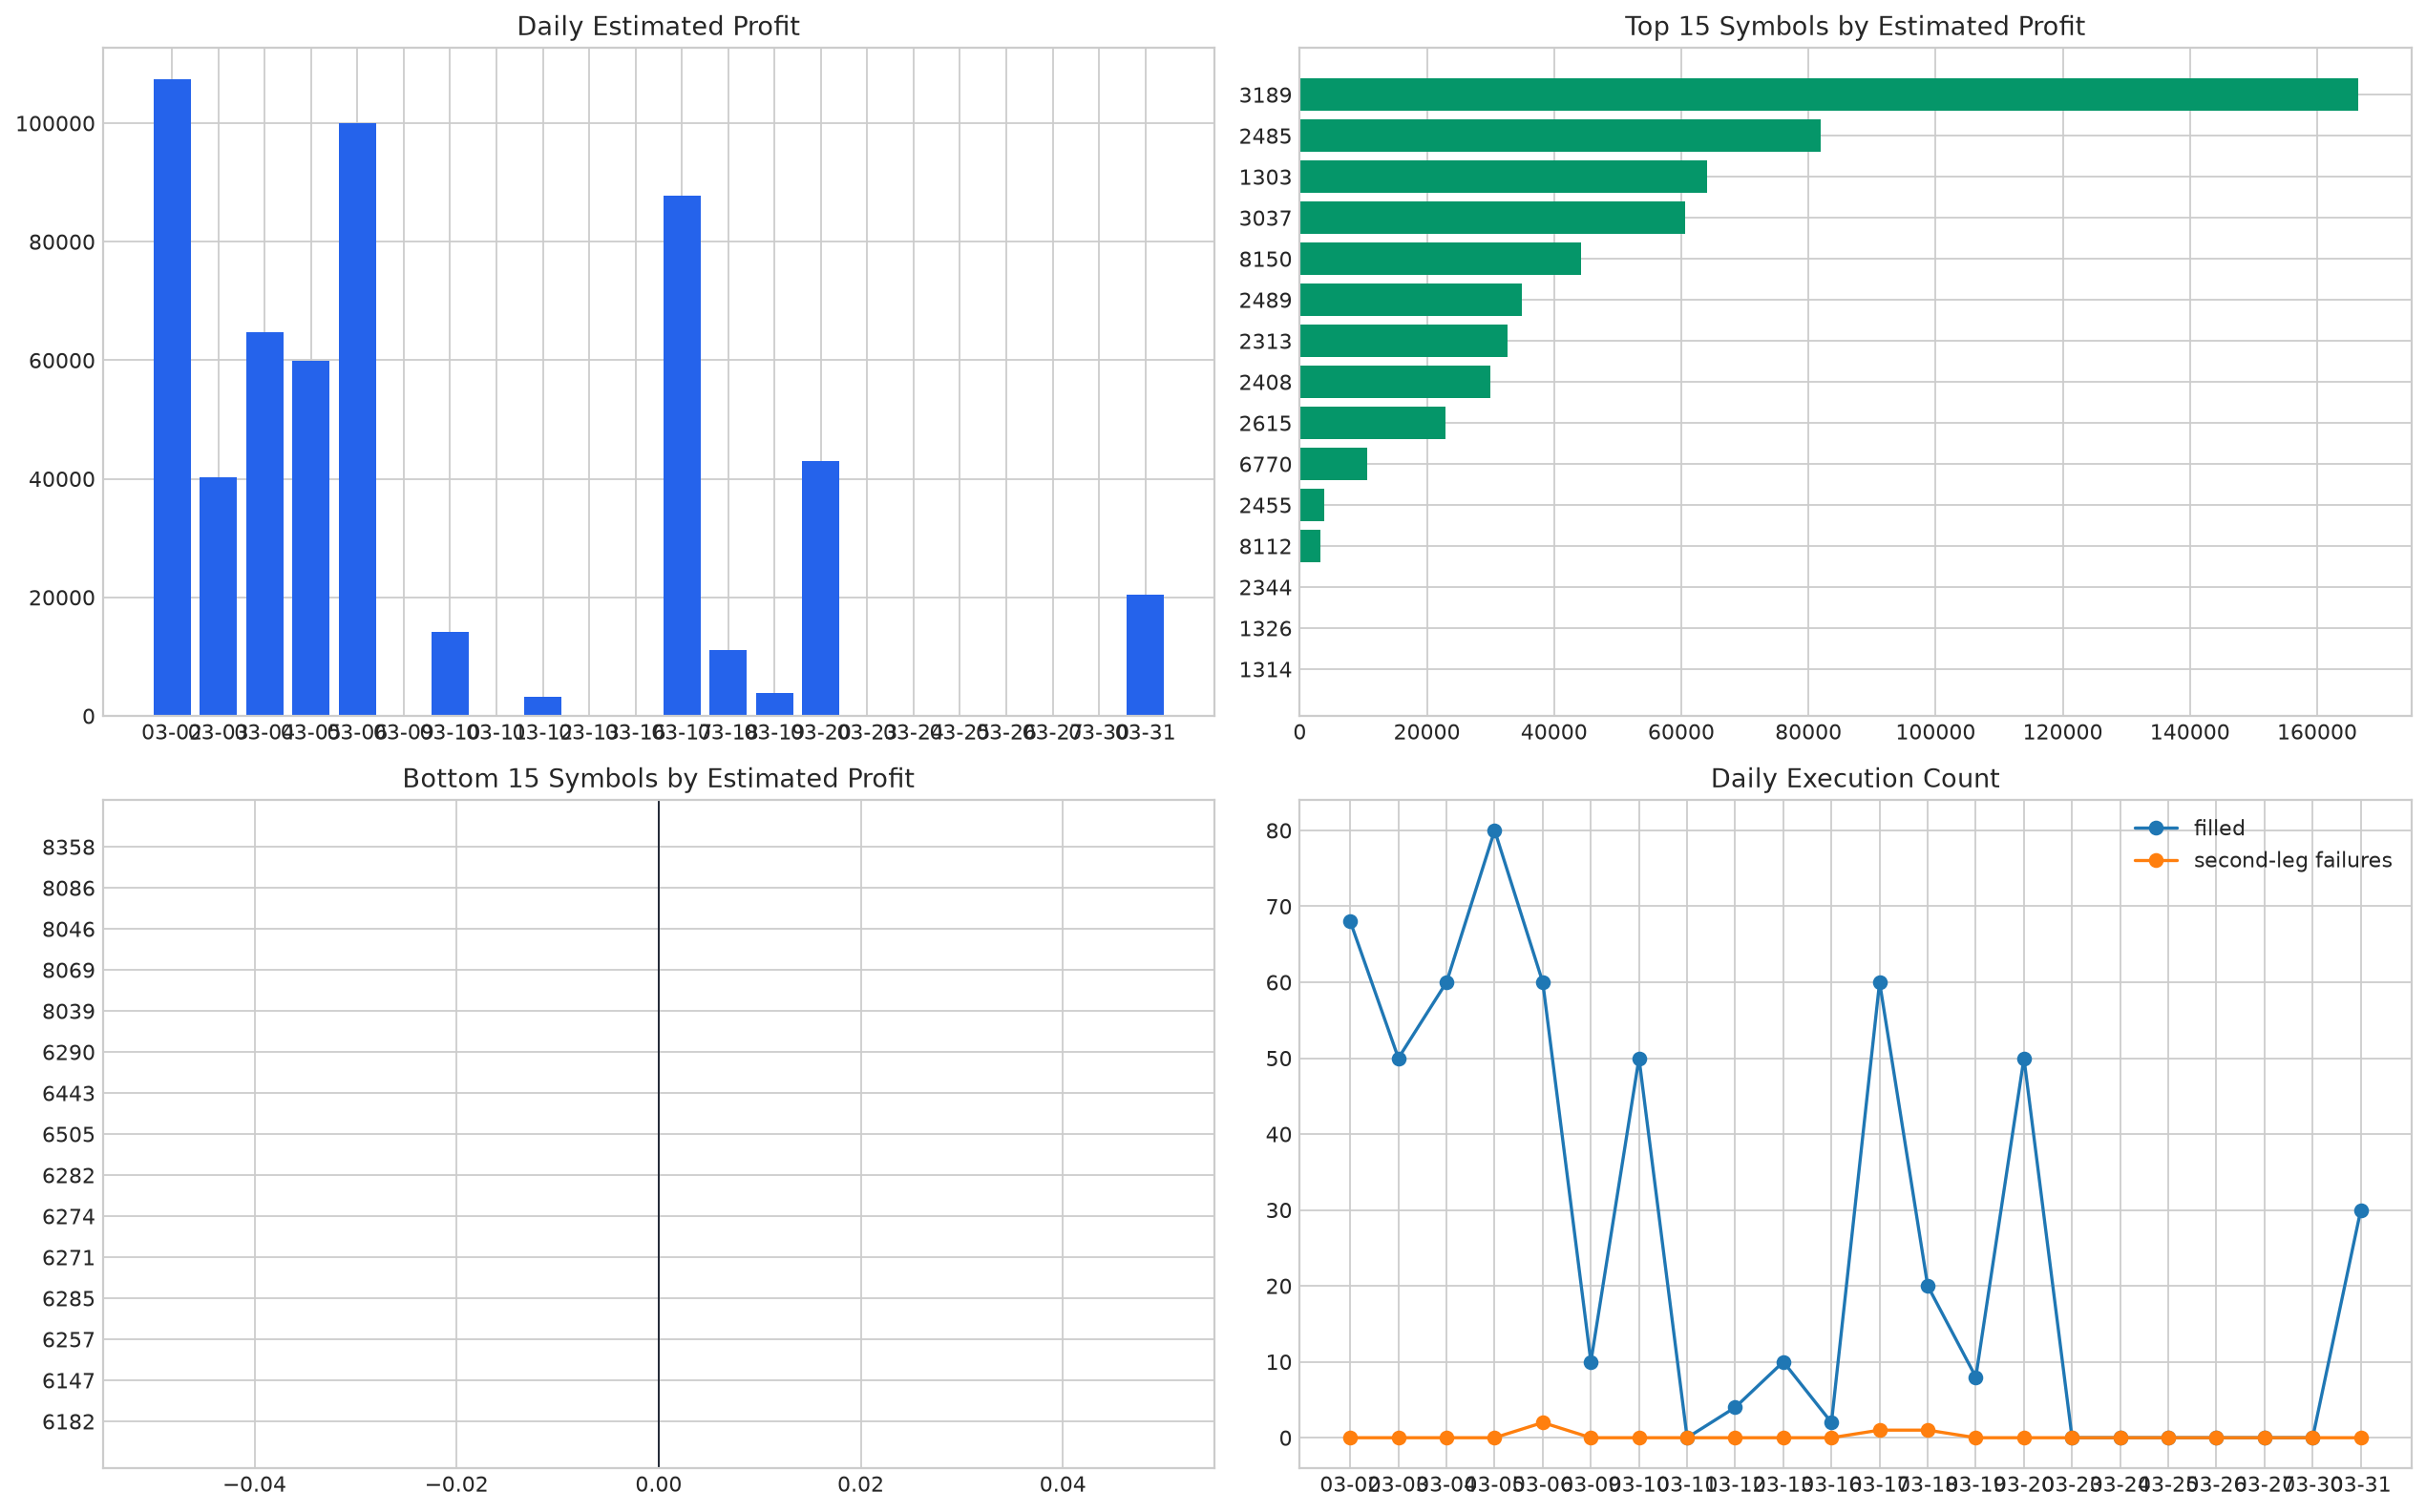

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/figures/pair_profit_scatter.png


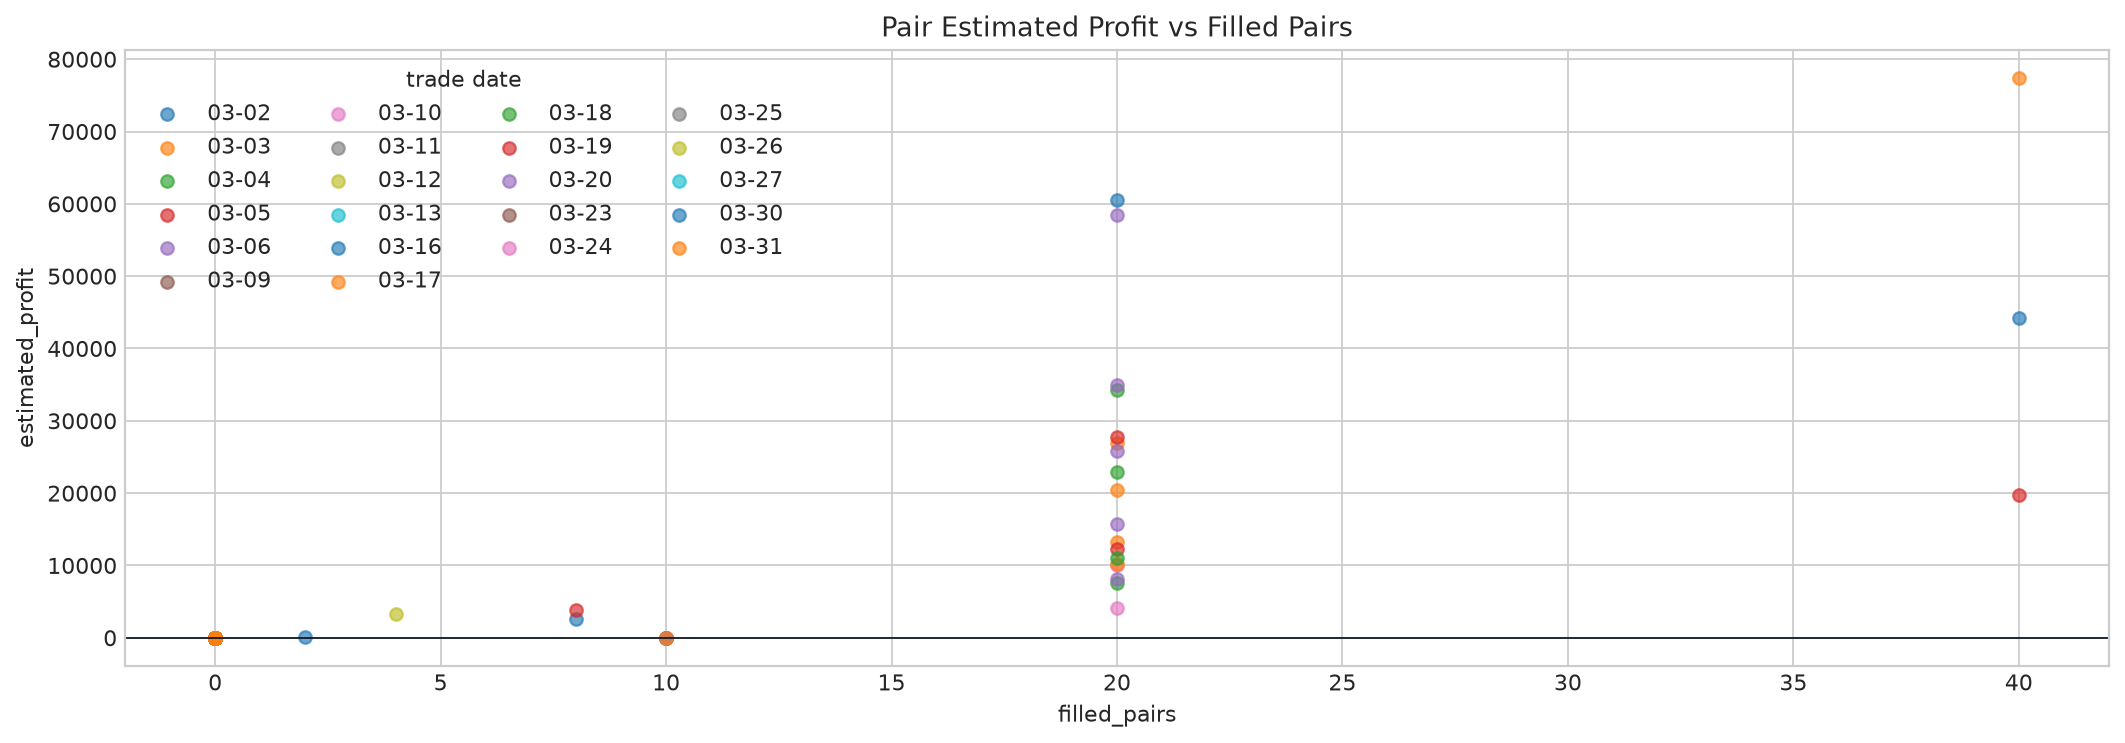

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/figures/stuck_cash.png


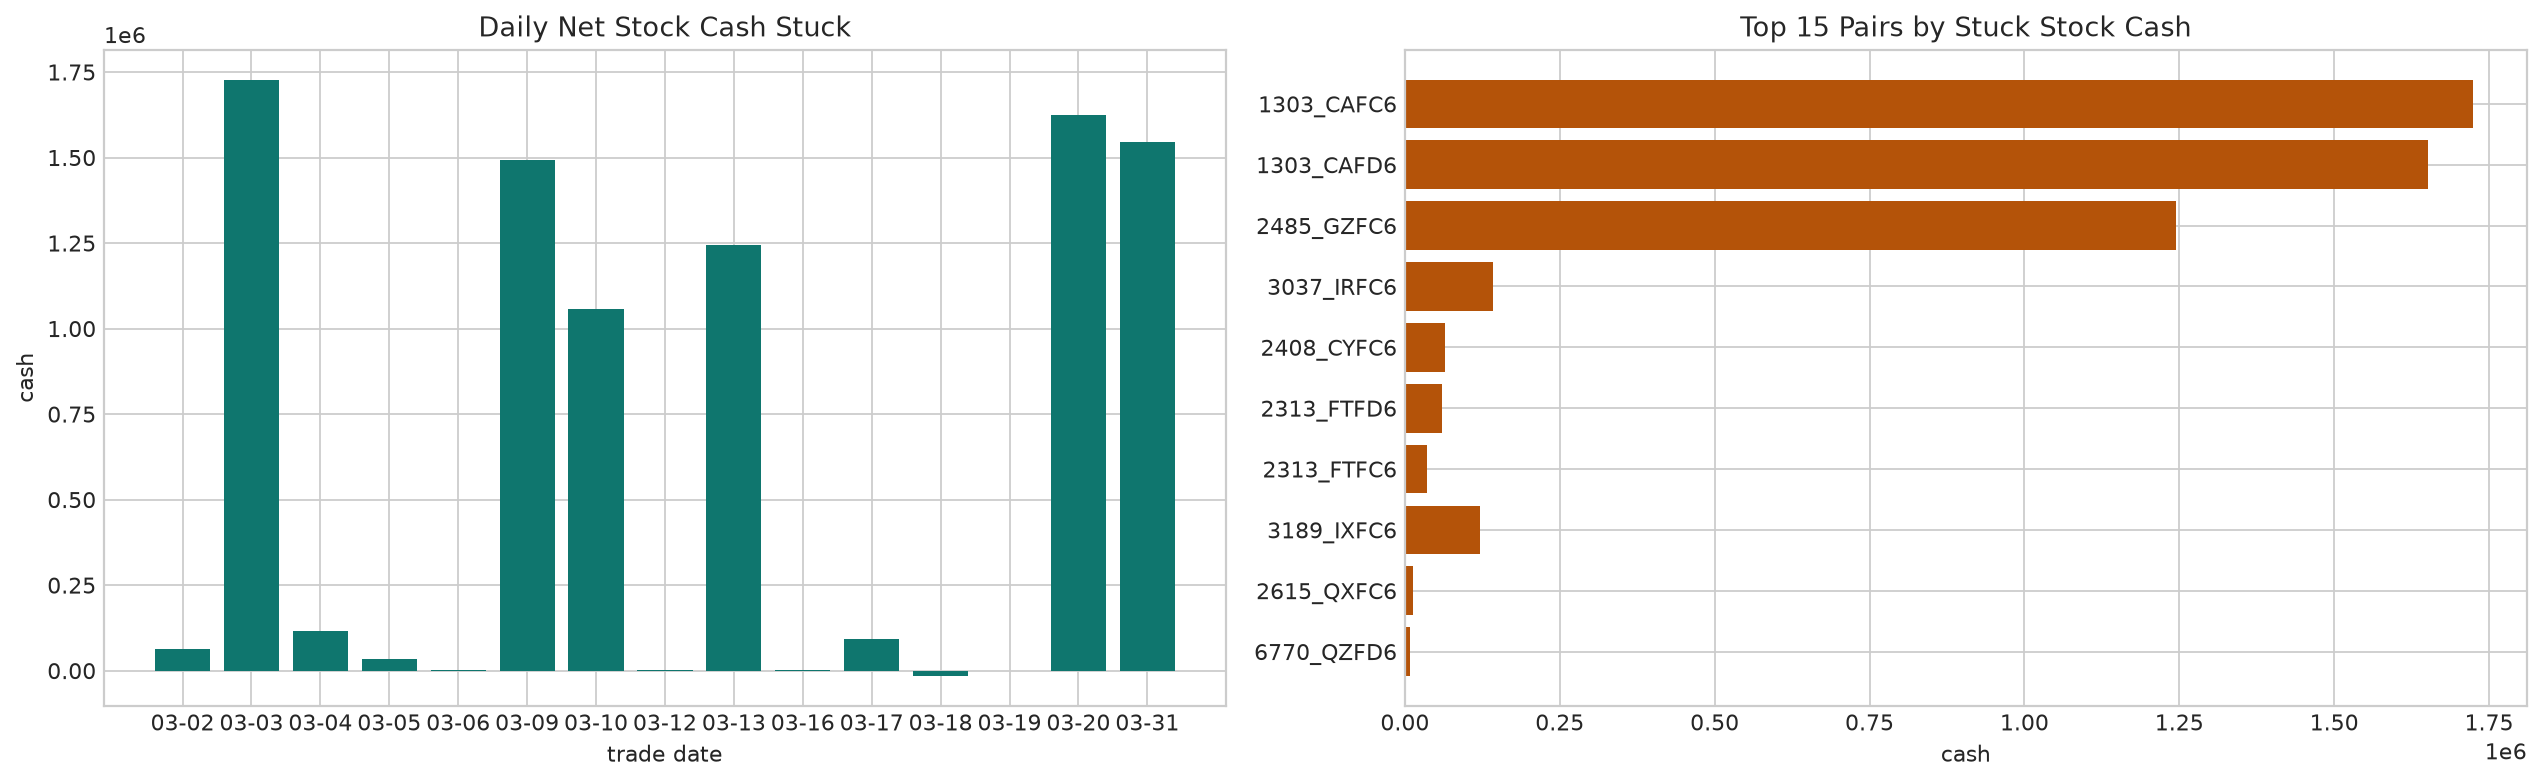

roi_including_open: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/figures/roi_including_open.png


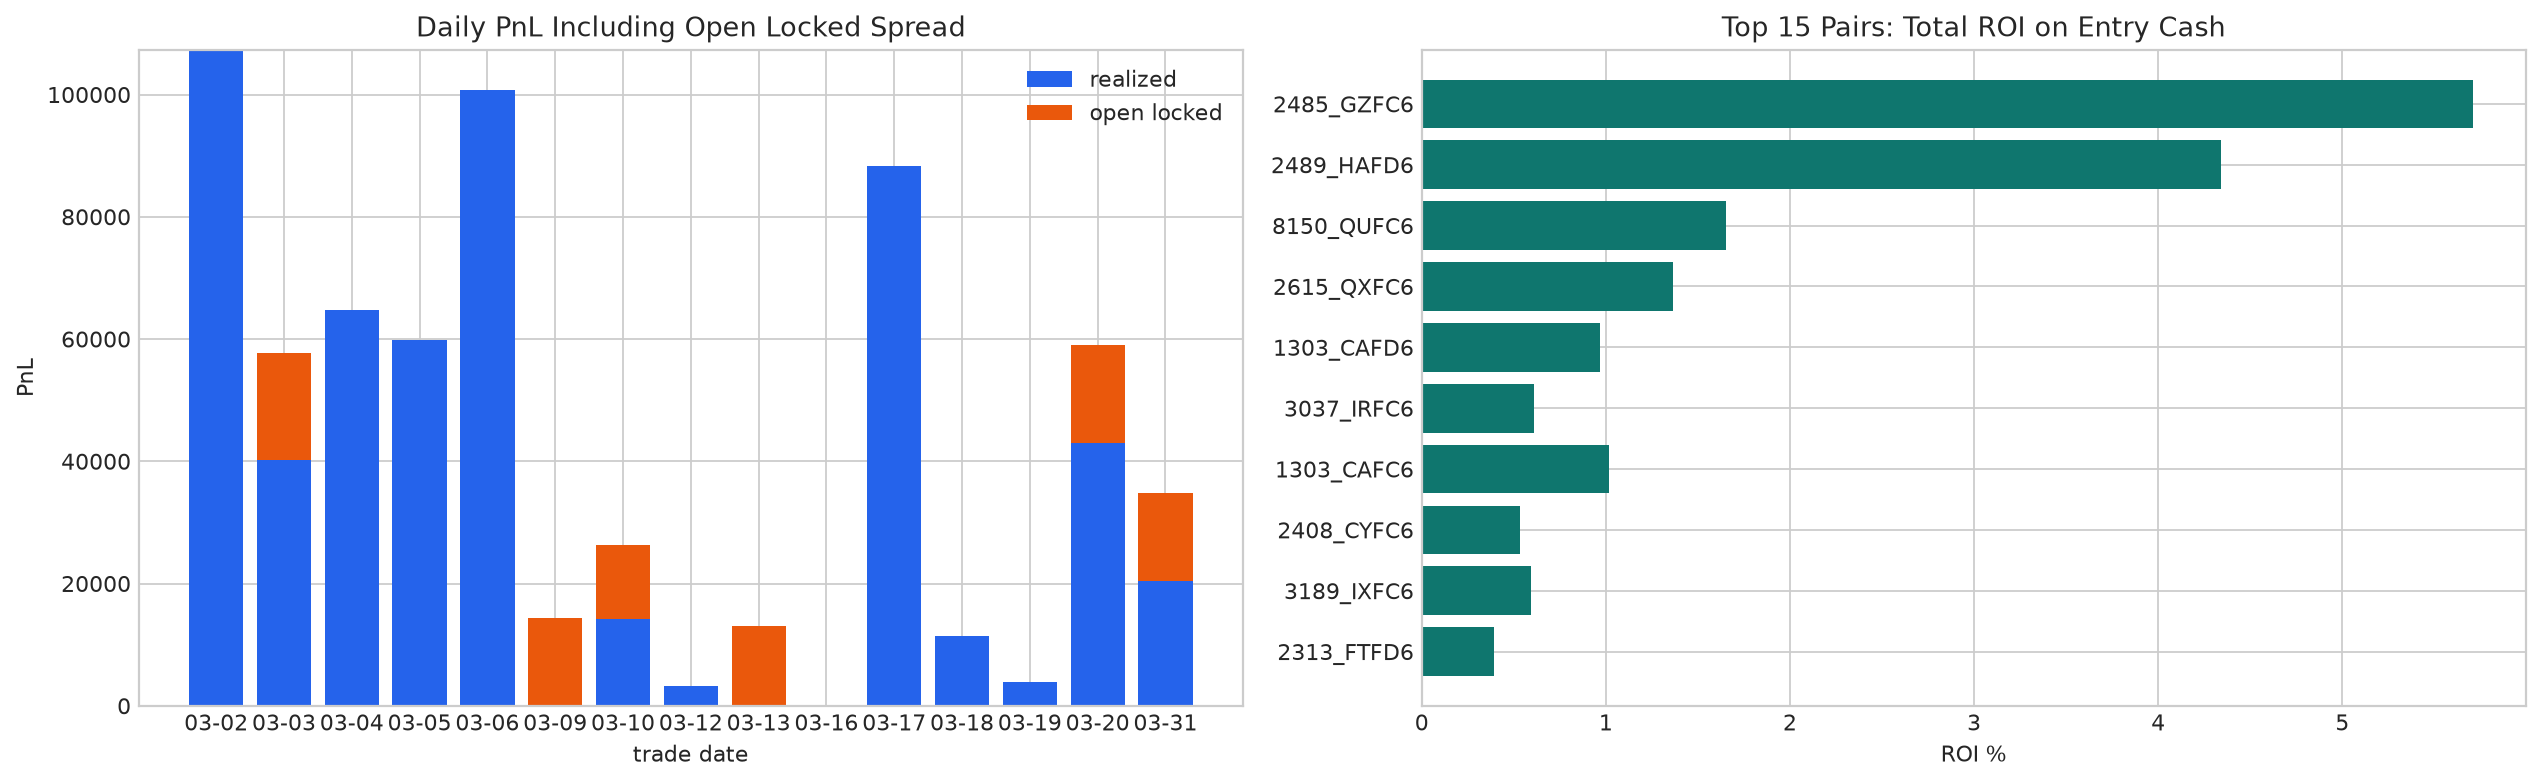

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms/figures/latency_timelines.png


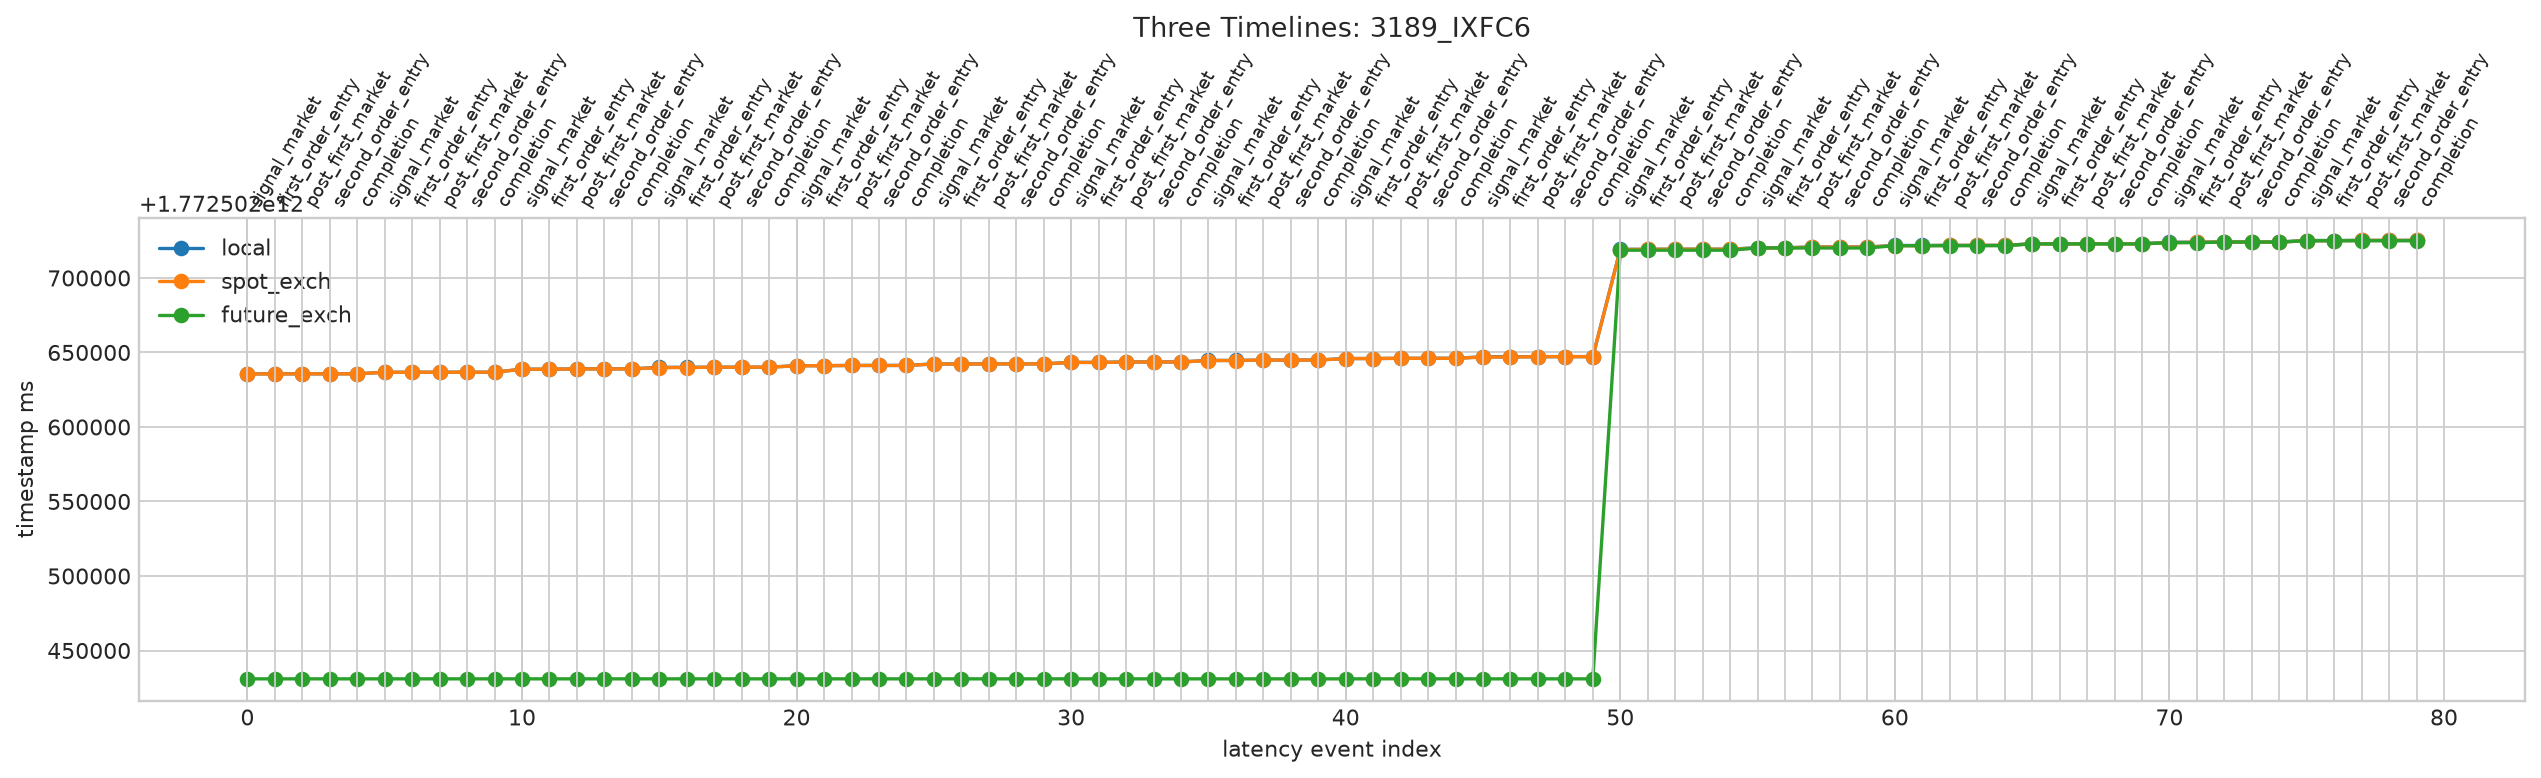

In [5]:
figure_paths = save_report_plots(artifacts, reports)
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. Optional Drill-down

In [6]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))

,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
27008,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:50:35.654000+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,315.0,315.5,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27009,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:50:35.714000+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,315.0,315.5,NaN,...,sell,320.0,320.0,1.0,stock,buy,316.5,315.5,2.0,40.000000
27010,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:50:36.714000+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,315.0,315.5,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27011,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:50:36.774000+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,315.0,315.5,NaN,...,sell,320.0,320.0,1.0,stock,buy,316.5,315.5,2.0,40.000000
27012,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:50:38.774000+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,315.0,315.5,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27103,2026-03-03,2026-03-03::3189_IXFC6,2026-03-03 09:52:09.944000+08:00,3189_IXFC6,3189,IXFC6,EXIT,316.5,317.0,NaN,...,buy,318.5,318.5,1.0,stock,sell,315.5,316.5,2.0,70.000128
27374,2026-03-04,2026-03-04::3189_IXFC6,2026-03-04 10:25:11.342952+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,289.5,290.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27375,2026-03-04,2026-03-04::3189_IXFC6,2026-03-04 10:25:11.782952+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,289.5,290.0,NaN,...,sell,294.0,294.0,1.0,stock,buy,291.0,290.0,2.0,420.000000
27376,2026-03-04,2026-03-04::3189_IXFC6,2026-03-04 10:25:12.782952+08:00,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,289.5,290.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
493,2026-03-03,2026-03-03::3189_IXFC6,1772502635654000000,3035,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1772502430982000000,1772502430992000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-03-03 09:50:35.654000+08:00
494,2026-03-03,2026-03-03::3189_IXFC6,1772502635674000000,3035,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1772502430982000000,1772502430992000000,10000000,1.772503e+18,1.772503e+18,1.772503e+18,10000000.0,10000000.0,2026-03-03 09:50:35.654000+08:00
495,2026-03-03,2026-03-03::3189_IXFC6,1772502635694000000,3035,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1772502430982000000,1772502430992000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-03-03 09:50:35.694000+08:00
496,2026-03-03,2026-03-03::3189_IXFC6,1772502635714000000,3035,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1772502430982000000,1772502430992000000,10000000,1.772503e+18,1.772503e+18,1.772503e+18,10000000.0,10000000.0,2026-03-03 09:50:35.694000+08:00
497,2026-03-03,2026-03-03::3189_IXFC6,1772502635714000000,3035,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,None,...,10000000,1772502430982000000,1772502430992000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-03-03 09:50:35.714000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,2026-03-04,2026-03-04::3189_IXFC6,1772591115312952000,5112,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,None,...,10000000,1772590647457000000,1772590647467000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-03-04 10:25:15.312952+08:00
709,2026-03-04,2026-03-04::3189_IXFC6,1772591115332952000,5112,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,None,...,10000000,1772590647457000000,1772590647467000000,10000000,1.772591e+18,1.772591e+18,1.772591e+18,10000000.0,10000000.0,2026-03-04 10:25:15.312952+08:00
710,2026-03-04,2026-03-04::3189_IXFC6,1772591115492952000,5112,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,None,...,10000000,1772590647457000000,1772590647467000000,10000000,NaN,NaN,NaN,NaN,NaN,2026-03-04 10:25:15.492952+08:00
711,2026-03-04,2026-03-04::3189_IXFC6,1772591115512952000,5112,3189_IXFC6,3189,IXFC6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,None,...,10000000,1772590647457000000,1772590647467000000,10000000,1.772591e+18,1.772591e+18,1.772591e+18,10000000.0,10000000.0,2026-03-04 10:25:15.492952+08:00
